# Dynamics and Numerical Integrators

Molecular dynamics asks a simple question with a difficult numerical answer: given positions, momenta, and forces now, where will the system be later? This notebook uses the harmonic oscillator to compare numerical integrators while separating short-time accuracy from long-time geometric behaviour.


## 1. Newtonian mechanics

Newton's second law relates force to acceleration,

$$
\mathbf F(\mathbf r)=m\mathbf a=-\nabla V(\mathbf r).
$$

For a one-dimensional harmonic oscillator, $F=-kq$ and $m\ddot q+kq=0$.

## 2. Lagrangian mechanics

With generalized coordinate $q$, the Lagrangian is $L=T-V$. The Euler--Lagrange equation,

$$
\frac{d}{dt}\frac{\partial L}{\partial \dot q}-\frac{\partial L}{\partial q}=0,
$$

gives the oscillator equation for $T=\tfrac12m\dot q^2$ and $V=\tfrac12kq^2$.

## 3. Hamiltonian mechanics

Using coordinate $q$ and conjugate momentum $p=m\dot q$,

$$
H(q,p)=\frac{p^2}{2m}+\frac12kq^2,
\qquad
\dot q=\frac{\partial H}{\partial p},\quad
\dot p=-\frac{\partial H}{\partial q}.
$$

Exact Hamiltonian flow preserves phase-space volume (Liouville's theorem). Energy conservation and phase-space preservation are related geometric properties, but they are not identical requirements for a discrete algorithm.

## 4. The harmonic oscillator as a benchmark

For $\omega=\sqrt{k/m}$,

$$
q(t)=q_0\cos(\omega t)+\frac{p_0}{m\omega}\sin(\omega t),
$$

$$
p(t)=p_0\cos(\omega t)-m\omega q_0\sin(\omega t).
$$

The trajectory is an ellipse in $(q,p)$ phase space and $H(q,p)$ is constant. The code below uses reduced units $m=k=\omega=1$; therefore momentum $p$ and velocity $v$ have the same numerical value.


# Numerical integrators

Discretising Hamilton's equations creates a map from $(q_n,p_n)$ to $(q_{n+1},p_{n+1})$. Accuracy over one step matters, but molecular dynamics also requires stable behaviour over millions of steps.

## Explicit Euler and phase-space expansion

Forward Euler updates both variables from the old state,

$$
q_{n+1}=q_n+p_n\Delta t,\qquad
p_{n+1}=p_n-\omega^2q_n\Delta t.
$$

For the harmonic oscillator its update matrix has $\det M=1+(\omega\Delta t)^2>1$. It therefore expands phase-space area at every step and injects energy into this oscillatory problem. Updating momentum first and then using the new momentum for position gives *symplectic Euler*, a different method with $\det M=1$.

## Velocity Verlet

Velocity Verlet is a second-order, time-reversible, symplectic splitting for a separable Hamiltonian $H=T(p)+V(q)$:

$$
q_{n+1}=q_n+v_n\Delta t+\frac12a_n\Delta t^2,
$$

$$
a_{n+1}=-\frac{1}{m}\left.\frac{dV}{dq}\right|_{q_{n+1}},
$$

$$
v_{n+1}=v_n+\frac12(a_n+a_{n+1})\Delta t.
$$

It does not conserve the exact Hamiltonian at every step. For a stable time step it follows a nearby shadow Hamiltonian, so the true-energy error is typically bounded and oscillatory rather than secular.

## Fixed-step classical RK4

The implementation below is the four-stage, fourth-order classical Runge--Kutta method (RK4). It is **not** the adaptive embedded RK4(5) method commonly called RK45. RK4 can have excellent short-time trajectory accuracy, but its map is not symplectic. A non-symplectic method does not necessarily lose energy monotonically: drift, dissipation, or growth depends on the method, time step, and problem.

## Methods compared

| Method | Global order | Symplectic | Time reversible | Main point here |
|---|---:|:---:|:---:|---|
| Explicit Euler | 1 | No | No | phase-space expansion |
| Symplectic Euler | 1 | Yes | No | bounded qualitative motion |
| RK2 midpoint | 2 | No | No | smaller local error |
| AB2 | 2 | No | No | multistep method |
| Leapfrog | 2 | Yes | Yes | staggered momentum |
| Velocity Verlet | 2 | Yes | Yes | standard MD workhorse |
| Classical RK4 | 4 | No | No | high short-time accuracy |

The integrator and the statistical ensemble are separate choices. A thermostat or barostat changes the equations being integrated; it does not cure an unstable time step or an unsuitable integrator.


## How to read the diagnostics

Each row below uses one time step. The position panel tests short-time phase accuracy, the phase portrait tests geometric behaviour, and the logarithmic energy panel exposes long-time error. A triangular boundary marker means that a trajectory has left the shared phase-space window; it is not silently clipped and treated as valid data.


# Code example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Reduced units: m = k = omega = 1, so momentum and velocity have equal values.
omega = 1.0
q0, p0 = 1.0, 0.0
y0 = np.array([q0, p0], dtype=float)

def harmonic_accel(q):
    return -(omega**2) * q

def analytical_solution(t, q_initial=q0, p_initial=p0):
    return q_initial * np.cos(omega * t) + (p_initial / omega) * np.sin(omega * t)

def analytical_momentum(t, q_initial=q0, p_initial=p0):
    return p_initial * np.cos(omega * t) - omega * q_initial * np.sin(omega * t)

def energy(q, p):
    return 0.5 * (p**2 + (omega * q) ** 2)

def make_time_grid(max_time, step):
    n_steps = int(round(max_time / step))
    t = np.arange(n_steps + 1, dtype=float) * step
    assert np.allclose(np.diff(t), step)
    return t

def _uniform_step(t):
    steps = np.diff(t)
    if len(steps) == 0 or not np.allclose(steps, steps[0]):
        raise ValueError("This demonstration assumes a non-empty, uniform time grid.")
    return float(steps[0])

def explicit_euler(f, initial, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    for i, h in enumerate(np.diff(t), start=1):
        q, p = y[i - 1]
        y[i] = q + h * p, p + h * f(q)
    return y

def symplectic_euler(f, initial, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    q, p = map(float, initial)
    for i, h in enumerate(np.diff(t), start=1):
        p += h * f(q)
        q += h * p
        y[i] = q, p
    return y

def rk2_midpoint(f, initial, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    for i, h in enumerate(np.diff(t), start=1):
        state = y[i - 1]
        q, p = state
        k1 = np.array([p, f(q)])
        q_mid, p_mid = state + 0.5 * h * k1
        k2 = np.array([p_mid, f(q_mid)])
        y[i] = state + h * k2
    return y

def ab2(f, initial, t):
    h = _uniform_step(t)
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    y[1] = rk2_midpoint(f, initial, t[:2])[1]
    for i in range(2, len(t)):
        q0_, p0_ = y[i - 2]
        q1_, p1_ = y[i - 1]
        y[i] = (
            q1_ + h * (1.5 * p1_ - 0.5 * p0_),
            p1_ + h * (1.5 * f(q1_) - 0.5 * f(q0_)),
        )
    return y

def leapfrog(f, initial, t):
    h = _uniform_step(t)
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    q, p = map(float, initial)
    p_half = p + 0.5 * h * f(q)
    for i in range(1, len(t)):
        q += h * p_half
        y[i] = q, p_half + 0.5 * h * f(q)
        p_half += h * f(q)
    return y

def velocity_verlet(f, initial, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    q, p = map(float, initial)
    for i, h in enumerate(np.diff(t), start=1):
        a = f(q)
        q_new = q + h * p + 0.5 * h**2 * a
        a_new = f(q_new)
        p_new = p + 0.5 * h * (a + a_new)
        y[i] = q_new, p_new
        q, p = q_new, p_new
    return y

def rk4(f, initial, t):
    def rhs(state):
        q, p = state
        return np.array([p, f(q)], dtype=float)

    y = np.zeros((len(t), 2), dtype=float)
    y[0] = initial
    for i, h in enumerate(np.diff(t), start=1):
        state = y[i - 1]
        k1 = rhs(state)
        k2 = rhs(state + 0.5 * h * k1)
        k3 = rhs(state + 0.5 * h * k2)
        k4 = rhs(state + h * k3)
        y[i] = state + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return y

METHODS = {
    "Explicit Euler": explicit_euler,
    "Symplectic Euler": symplectic_euler,
    "RK2 midpoint": rk2_midpoint,
    "AB2": ab2,
    "Leapfrog": leapfrog,
    "Velocity Verlet": velocity_verlet,
    "Classical RK4": rk4,
}
TIMESTEPS = (0.05, 0.10, 0.50)
MAX_TIME = 80.0
results = {}

for step in TIMESTEPS:
    t = make_time_grid(MAX_TIME, step)
    exact = np.column_stack((analytical_solution(t), analytical_momentum(t)))
    results[step] = {
        "t": t,
        "Analytical": exact,
        **{name: method(harmonic_accel, y0, t) for name, method in METHODS.items()},
    }

# Structural and convergence checks used by the narrative.
for step in TIMESTEPS:
    explicit_matrix = np.array([[1.0, step], [-(omega**2) * step, 1.0]])
    symplectic_matrix = np.array(
        [[1.0 - (omega * step) ** 2, step], [-(omega**2) * step, 1.0]]
    )
    assert np.isclose(np.linalg.det(explicit_matrix), 1.0 + (omega * step) ** 2)
    assert np.isclose(np.linalg.det(symplectic_matrix), 1.0)

vv_errors = []
for step in (0.20, 0.10, 0.05):
    t_check = make_time_grid(10.0, step)
    vv = velocity_verlet(harmonic_accel, y0, t_check)
    vv_errors.append(np.max(np.abs(vv[:, 0] - analytical_solution(t_check))))
observed_orders = np.log2(np.array(vv_errors[:-1]) / np.array(vv_errors[1:]))
assert np.all(observed_orders > 1.9), observed_orders

print("Velocity Verlet observed orders:", np.round(observed_orders, 3))
print("\nMaximum relative energy error at dt = 0.10")
reference_energy = energy(q0, p0)
for name, values in results[0.10].items():
    if name in {"t", "Analytical"}:
        continue
    rel_error = np.max(np.abs(energy(values[:, 0], values[:, 1]) - reference_energy)) / reference_energy
    print(f"{name:18s} {rel_error:12.4e}")


Velocity Verlet observed orders: [2.004 2.001]

Maximum relative energy error at dt = 0.10
Explicit Euler       2.8638e+03
Symplectic Euler     5.2631e-02
RK2 midpoint         2.0201e-02
AB2                  4.1655e-02
Leapfrog             2.5000e-03
Velocity Verlet      2.5000e-03
Classical RK4        1.1097e-05


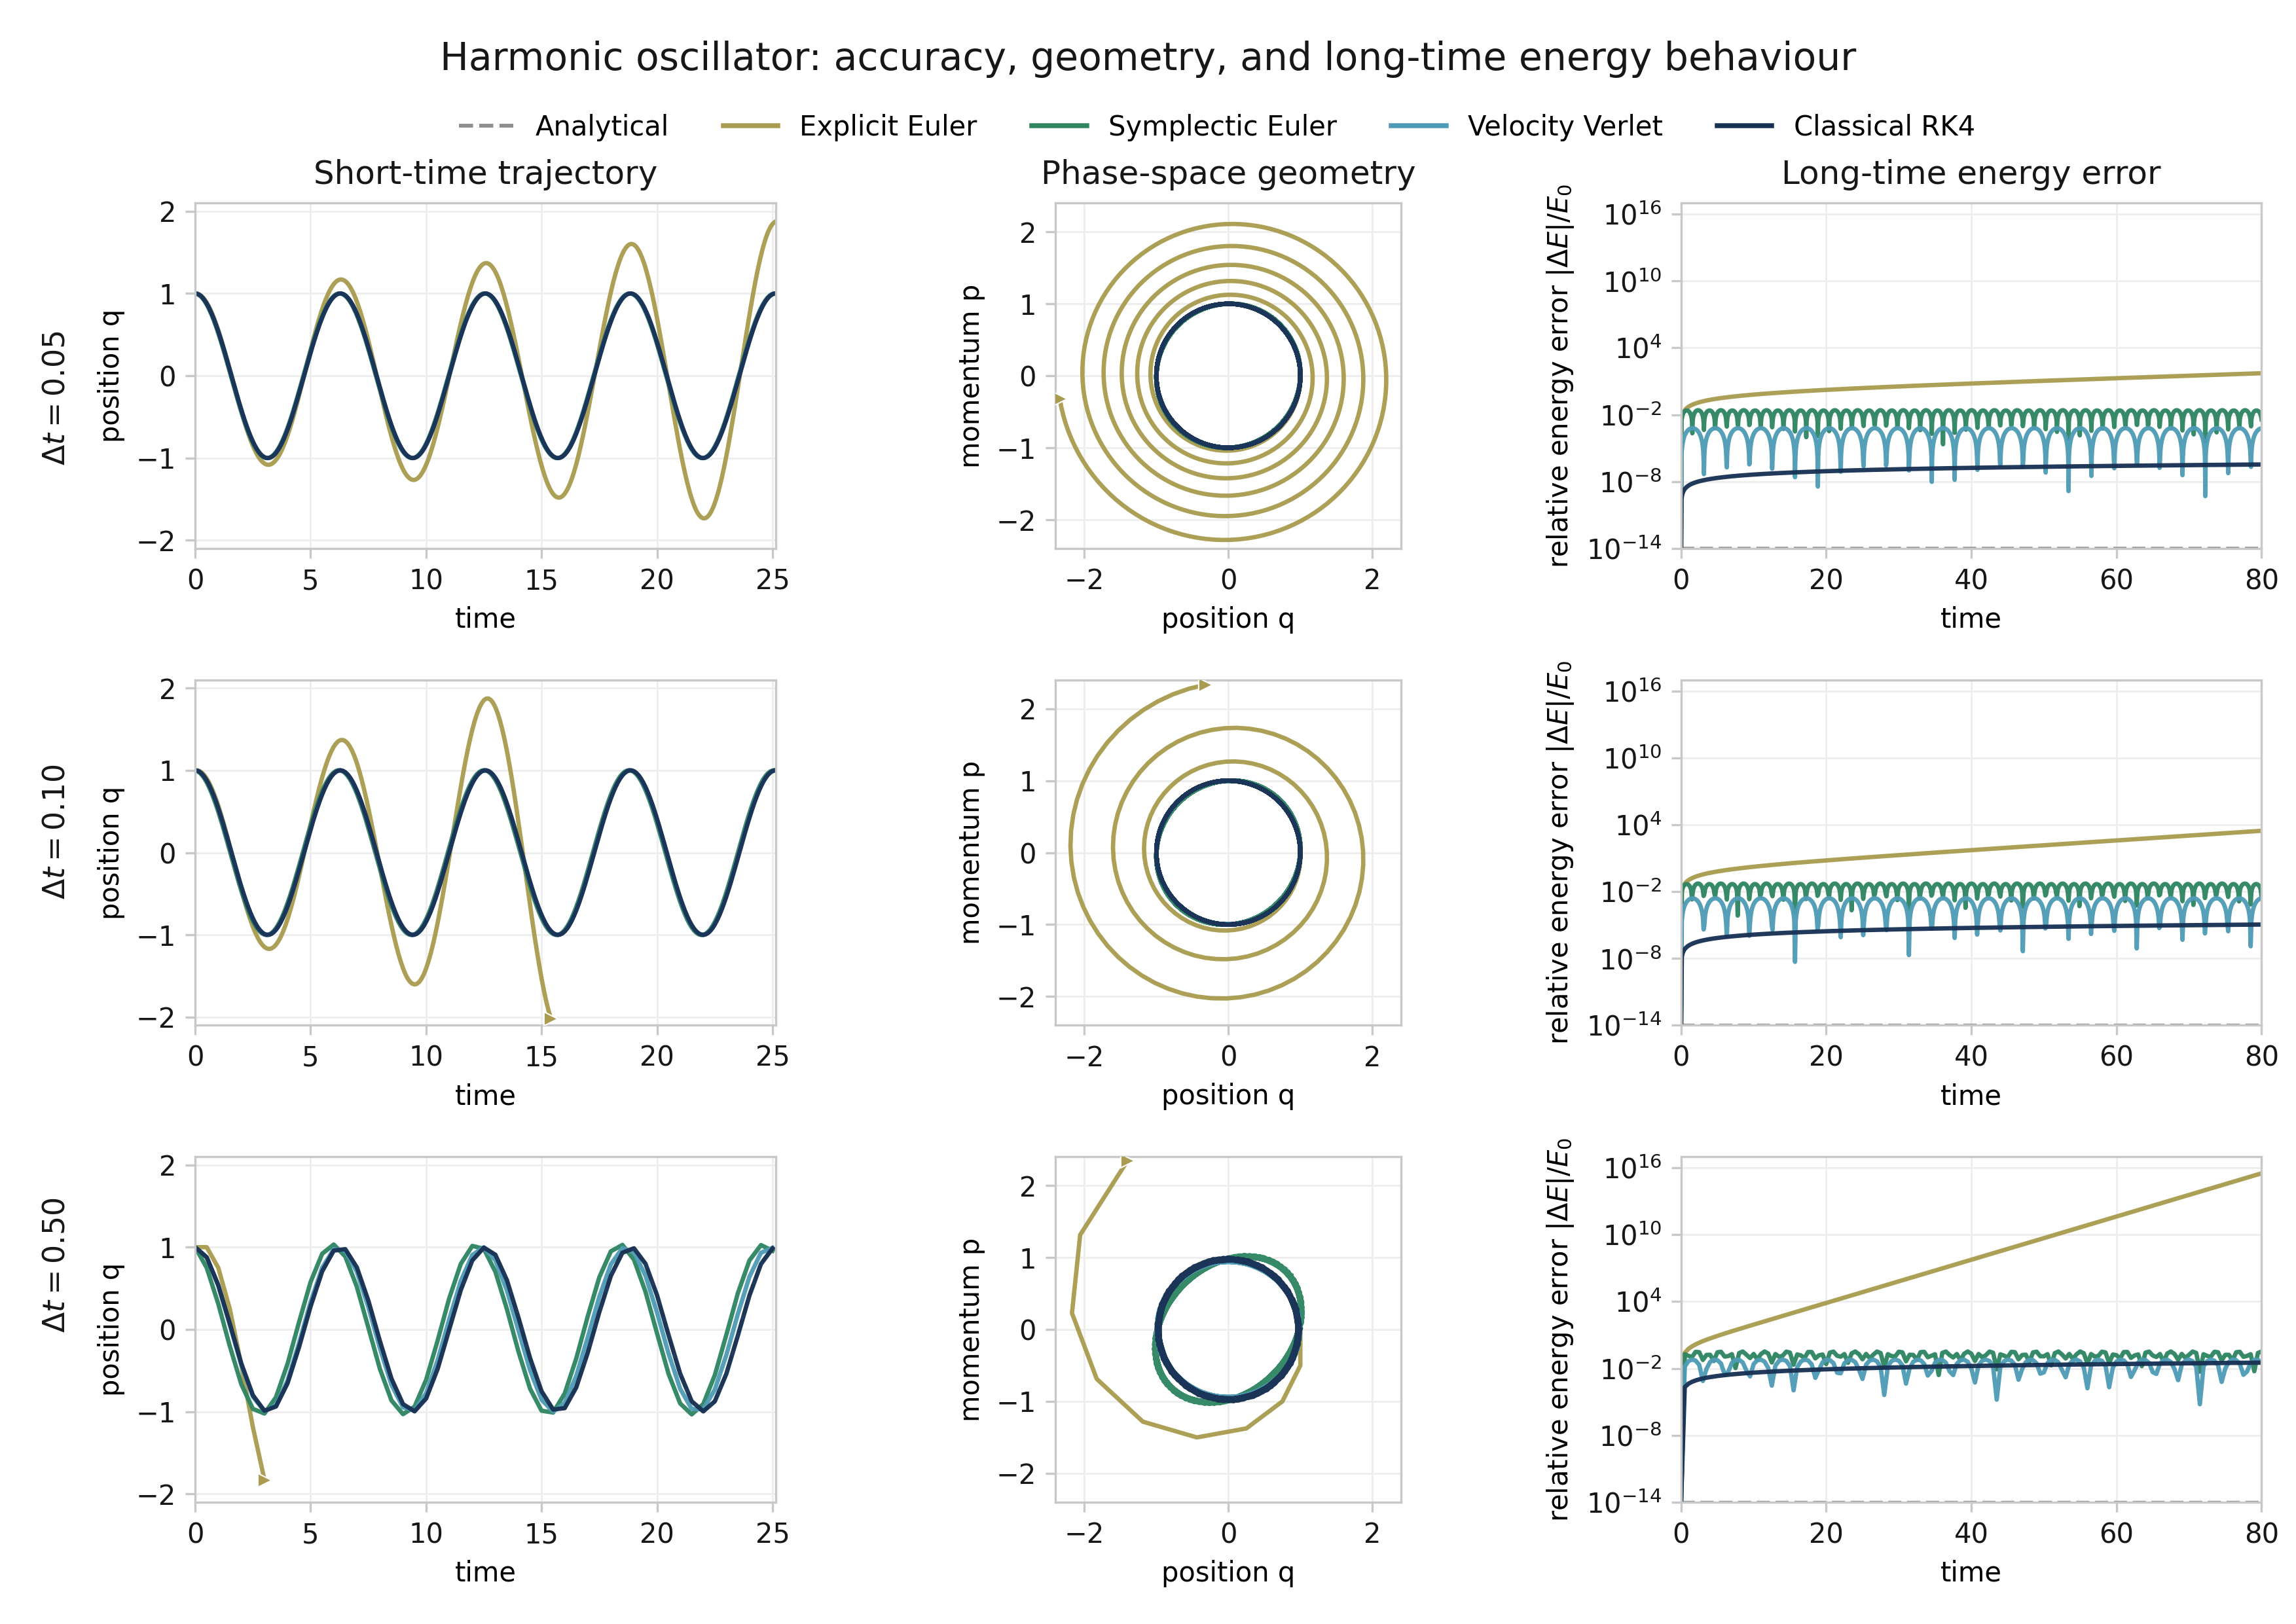

<cell 6>:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
Saved integrator_animations\figures\integrator_comparison.png and integrator_animations\figures\integrator_comparison.pdf


In [2]:
# Unified A4 landscape comparison following the project visual system.
WHITE = "#FFFFFF"
INK = "#171717"
MID_GRAY = "#8E8E8E"
LINE_GRAY = "#C8C8C8"
LIGHT_GRAY = "#EEEEEE"
NAVY = "#183153"
FORCE_OLIVE = "#A99C50"
VELOCITY_EMERALD = "#2F8562"
POSITION_LAKE = "#4E9BB5"

COLORS = {
    "Analytical": MID_GRAY,
    "Explicit Euler": FORCE_OLIVE,
    "Symplectic Euler": VELOCITY_EMERALD,
    "Velocity Verlet": POSITION_LAKE,
    "Classical RK4": NAVY,
}
DISPLAY_METHODS = tuple(COLORS)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": LINE_GRAY,
    "axes.linewidth": 0.8,
    "axes.facecolor": WHITE,
    "figure.facecolor": WHITE,
    "savefig.facecolor": WHITE,
})

def style_axes(ax):
    ax.grid(color=LIGHT_GRAY, linewidth=0.7, zorder=0)
    ax.tick_params(color=LINE_GRAY, labelcolor=INK, width=0.8)
    for spine in ax.spines.values():
        spine.set_color(LINE_GRAY)

def prefix_inside_box(values, limit=2.35):
    inside = np.maximum(np.abs(values[:, 0]), np.abs(values[:, 1])) <= limit
    outside = np.flatnonzero(~inside)
    stop = int(outside[0]) if len(outside) else len(values)
    return max(stop, 2), bool(len(outside))

def prefix_inside_scalar(values, limit=2.05):
    outside = np.flatnonzero(np.abs(values) > limit)
    stop = int(outside[0]) if len(outside) else len(values)
    return max(stop, 2), bool(len(outside))

fig, axes = plt.subplots(3, 3, figsize=(11.69, 8.27))
fig.subplots_adjust(left=0.085, right=0.985, bottom=0.075, top=0.875, wspace=0.28, hspace=0.38)
fig.suptitle(
    "Harmonic oscillator: accuracy, geometry, and long-time energy behaviour",
    fontsize=14, color=INK, y=0.975,
)

legend_handles = []
for name in DISPLAY_METHODS:
    line_style = "--" if name == "Analytical" else "-"
    linewidth = 1.4 if name == "Analytical" else 1.8
    handle, = axes[0, 0].plot([], [], color=COLORS[name], ls=line_style, lw=linewidth, label=name)
    legend_handles.append(handle)
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.53, 0.945), ncol=5, frameon=False)

for row, step in enumerate(TIMESTEPS):
    data = results[step]
    t = data["t"]
    short = t <= 8.0 * np.pi
    ax_q, ax_phase, ax_energy = axes[row]

    for name in DISPLAY_METHODS:
        values = data[name]
        ls = "--" if name == "Analytical" else "-"
        lw = 1.3 if name == "Analytical" else 1.6
        short_count = int(np.count_nonzero(short))
        q_stop, q_exited = prefix_inside_scalar(values[:, 0])
        q_stop = min(q_stop, short_count)
        ax_q.plot(t[:q_stop], values[:q_stop, 0], color=COLORS[name], ls=ls, lw=lw, alpha=0.96)
        if q_exited and q_stop < short_count and name != "Analytical":
            ax_q.scatter(
                t[q_stop - 1], values[q_stop - 1, 0],
                marker=">", s=26, color=COLORS[name], edgecolor=WHITE,
                linewidth=0.5, zorder=5, clip_on=True,
            )

        stop, exited = prefix_inside_box(values)
        ax_phase.plot(values[:stop, 0], values[:stop, 1], color=COLORS[name], ls=ls, lw=lw, alpha=0.96)
        if exited and name != "Analytical":
            ax_phase.scatter(
                values[stop - 1, 0], values[stop - 1, 1],
                marker=">", s=26, color=COLORS[name], edgecolor=WHITE,
                linewidth=0.5, zorder=5, clip_on=True,
            )

        relative = np.abs(energy(values[:, 0], values[:, 1]) - energy(q0, p0)) / energy(q0, p0)
        ax_energy.plot(t, np.maximum(relative, 1e-14), color=COLORS[name], ls=ls, lw=lw, alpha=0.96)

    ax_q.set(xlim=(0.0, 8.0 * np.pi), ylim=(-2.1, 2.1), xlabel="time", ylabel="position q")
    ax_phase.set(xlim=(-2.4, 2.4), ylim=(-2.4, 2.4), xlabel="position q", ylabel="momentum p")
    ax_phase.set_aspect("equal", adjustable="box")
    ax_energy.set_yscale("log")
    ax_energy.set(xlim=(0.0, MAX_TIME), ylim=(1e-14, 1e17), xlabel="time")
    ax_energy.set_ylabel(r"relative energy error $|\Delta E|/E_0$")

    for ax in (ax_q, ax_phase, ax_energy):
        style_axes(ax)

    fig.text(0.018, 0.755 - row * 0.267, rf"$\Delta t={step:.2f}$", rotation=90, fontsize=11, color=INK, va="center")

axes[0, 0].set_title("Short-time trajectory", color=INK, pad=7)
axes[0, 1].set_title("Phase-space geometry", color=INK, pad=7)
axes[0, 2].set_title("Long-time energy error", color=INK, pad=7)

output_dir = Path("integrator_animations/figures")
output_dir.mkdir(parents=True, exist_ok=True)
png_path = output_dir / "integrator_comparison.png"
pdf_path = output_dir / "integrator_comparison.pdf"
fig.savefig(png_path, dpi=300)
fig.savefig(pdf_path)
plt.show()
print(f"Saved {png_path} and {pdf_path}")
